#### **Setup**

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error
import kagglehub
from dotenv import load_dotenv

def set_seed(seed: int = 67):
    # random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1488)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

#### **Dataset**

In [2]:
load_dotenv() 

path = kagglehub.competition_download('ventilator-pressure-prediction')

print("Path to competition files:", path)

df_train = pd.read_csv(path+"/train.csv")
df_test  = pd.read_csv(path+"/test.csv")

Path to competition files: /root/.cache/kagglehub/competitions/ventilator-pressure-prediction


#### **EDA**

Columns

**id** - globally-unique time step identifier across an entire file

**breath_id** - globally-unique time step for breaths

**R** - lung attribute indicating how restricted the airway is (in cmH2O/L/S). Physically, this is the change in pressure per change in flow (air volume per time). Intuitively, one can imagine blowing up a balloon through a straw. We can change R by changing the diameter of the straw, with higher R being harder to blow.

**C** - lung attribute indicating how compliant the lung is (in mL/cmH2O). Physically, this is the change in volume per change in pressure. Intuitively, one can imagine the same balloon example. We can change C by changing the thickness of the balloon’s latex, with higher C having thinner latex and easier to blow.

**time_step** - the actual time stamp.

**u_in** - the control input for the inspiratory solenoid valve. Ranges from 0 to 100.

**u_out** - the control input for the exploratory solenoid valve. Either 0 or 1.

**pressure** - the airway pressure measured in the respiratory circuit, measured in cmH2O.

In [3]:
df_train.info() 
df_train.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB


,id,breath_id,R,C,time_step,u_in,u_out,pressure
count,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06
mean,3.018000e+06,6.283886e+04,2.703618e+01,2.608072e+01,1.307225e+00,7.321615e+00,6.204493e-01,1.122041e+01
std,1.742443e+06,3.633526e+04,1.959549e+01,1.715231e+01,7.659778e-01,1.343470e+01,4.852752e-01,8.109703e+00
min,1.000000e+00,1.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-1.895744e+00
25%,1.509001e+06,3.137700e+04,5.000000e+00,1.000000e+01,6.428995e-01,3.936623e-01,0.000000e+00,6.329607e+00
50%,3.018000e+06,6.276550e+04,2.000000e+01,2.000000e+01,1.308123e+00,4.386146e+00,1.000000e+00,7.032628e+00
75%,4.527000e+06,9.430100e+04,5.000000e+01,5.000000e+01,1.965502e+00,4.983895e+00,1.000000e+00,1.364103e+01
max,6.036000e+06,1.257490e+05,5.000000e+01,5.000000e+01,2.937238e+00,1.000000e+02,1.000000e+00,6.482099e+01


In [4]:
df_test.info() 
df_test.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024000 entries, 0 to 4023999
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
dtypes: float64(2), int64(5)
memory usage: 214.9 MB


,id,breath_id,R,C,time_step,u_in,u_out
count,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06
mean,2.012000e+06,6.292796e+04,2.710785e+01,2.607038e+01,1.307083e+00,7.338098e+00,6.203864e-01
std,1.161629e+06,3.624924e+04,1.954281e+01,1.717103e+01,7.658902e-01,1.350955e+01,4.852908e-01
min,1.000000e+00,0.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.006001e+06,3.153050e+04,5.000000e+00,1.000000e+01,6.428454e-01,4.096735e-01,0.000000e+00
50%,2.012000e+06,6.305750e+04,2.000000e+01,2.000000e+01,1.308083e+00,4.377512e+00,1.000000e+00
75%,3.018000e+06,9.433325e+04,5.000000e+01,5.000000e+01,1.965240e+00,4.983472e+00,1.000000e+00
max,4.024000e+06,1.257480e+05,5.000000e+01,5.000000e+01,2.935203e+00,1.000000e+02,1.000000e+00


In [5]:
df_train.isnull().sum(), df_test.isnull().sum(), df_train.duplicated().sum(), df_test.duplicated().sum() 

(id           0
 breath_id    0
 R            0
 C            0
 time_step    0
 u_in         0
 u_out        0
 pressure     0
 dtype: int64,
 id           0
 breath_id    0
 R            0
 C            0
 time_step    0
 u_in         0
 u_out        0
 dtype: int64,
 np.int64(0),
 np.int64(0))

In [6]:
df_train.nunique().to_frame()

,0
id,6036000
breath_id,75450
R,3
C,3
time_step,3767571
u_in,4020300
u_out,2
pressure,950


<Axes: >

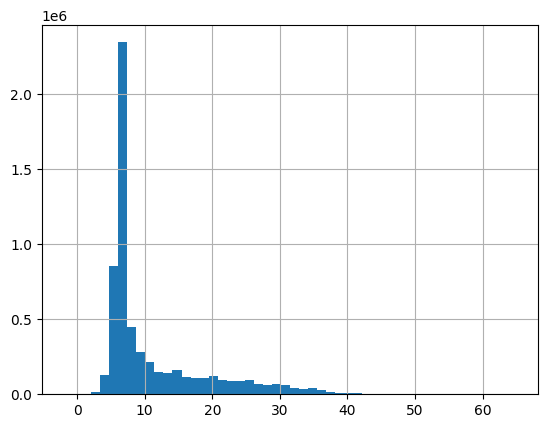

In [7]:
df_train['pressure'].hist(bins=50)

In [8]:
breath_one = df_train[(df_train['breath_id'] == 1)]
breath_one

,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987
...,...,...,...,...,...,...,...,...
75,76,1,20,50,2.553593,4.974474,1,6.399909
76,77,1,20,50,2.587754,4.978481,1,6.610815
77,78,1,20,50,2.621773,4.981847,1,6.329607
78,79,1,20,50,2.655746,4.984683,1,6.540513


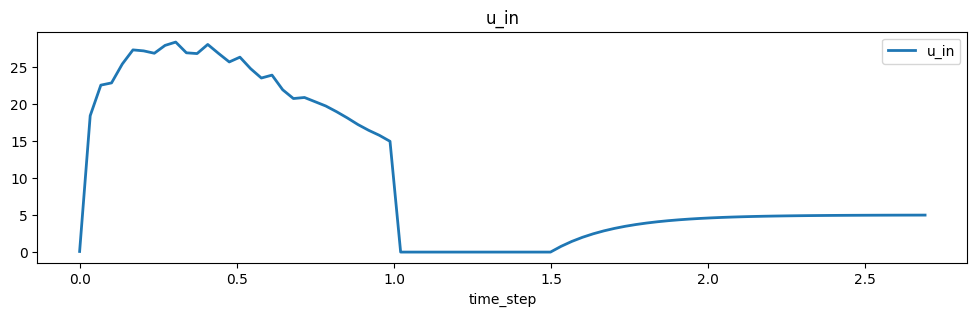

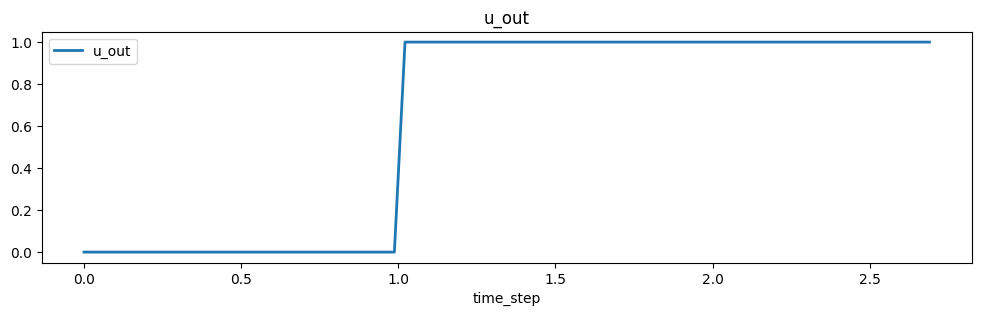

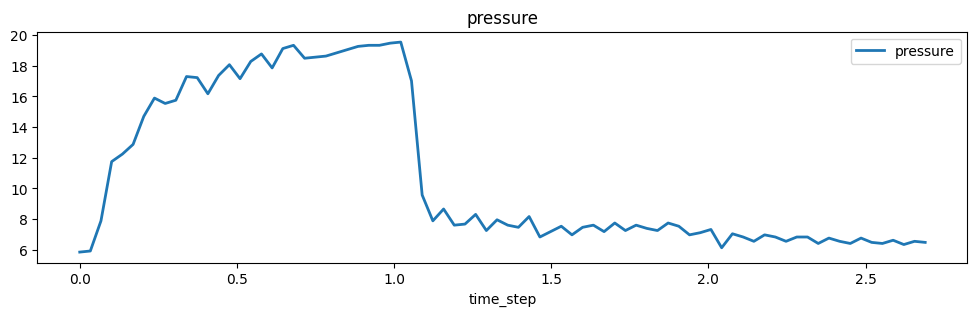

In [9]:
breath_one.plot(x="time_step", y="u_in", kind='line',figsize=(12,3), lw=2, title="u_in");
breath_one.plot(x="time_step", y="u_out", kind='line',figsize=(12,3), lw=2, title="u_out");
breath_one.plot(x="time_step", y="pressure", kind='line',figsize=(12,3), lw=2, title="pressure");

In [10]:
pd.crosstab(df_train["R"],df_train["C"])/60000

C,10,20,50
R,,,
5,11.082667,11.036000,11.028000
20,8.093333,8.277333,10.914667
50,18.236000,11.013333,10.918667


In [11]:
pd.crosstab(df_test["R"],df_test["C"])/40000

C,10,20,50
R,,,
5,10.874,10.902,10.894
20,8.584,8.176,11.000
50,18.162,11.006,11.002


#### **Adversarial validation**

In [12]:
av_model = LogisticRegression()
av_data = pd.concat([df_train.assign(is_test=0),
                     df_test.assign(is_test=1)])

X = av_data.drop(columns=['id', 'breath_id', 'pressure', 'is_test'])
y = av_data['is_test']

av_model.fit(X, y)
y_pred = av_model.predict(X)

In [13]:
print(roc_auc_score(y, y_pred))
print("Happy!")

0.5
Happy!


#### **Target metric**

The official metric is MAE (mean absolute error). 
    $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
It is easy to understand, implement and from what internet says it tends to optimize the model to median solution. But it has it's weaknesses: the error increases linearly, which means that extreme outliers are weighted the same as small errors.

I propose two metrics as an alternative :
1. MSE - it is an industry standart metric that penaltizes outliers rather than small mistakes. It can be used as a loss function for optimization and I will try to train two models for both MAE and MSE and then compare their performance.
    $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
2. Tolerance accuracy - it is here only because I thought it would be interesting to see what fraction of time our modelpredicts the preassure in some threshold near the actual value, and then I found out there is a metric for that. I will use it mostly to get some insights during validation.
    $$\text{Tolerance Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{I}\left(|y_i - \hat{y}_i| \le \epsilon\right)$$

#### **Validation**

In [14]:
breath_groups = df_train[["breath_id", "R", "C"]].drop_duplicates()
breath_groups["R_C"] = breath_groups["R"].astype(str)+'_'+breath_groups["C"].astype(str)

breath_train, breath_val = train_test_split(breath_groups["breath_id"], train_size=0.67, stratify=breath_groups["R_C"])

df_val   = df_train[df_train["breath_id"].isin(breath_val)].copy()
df_train = df_train[df_train["breath_id"].isin(breath_train)].copy()

In [15]:
class GoogleBrainDataset(Dataset):
    def __init__(self, df, is_test=False):
        self.is_test = is_test
        df = df.drop(columns=['id', 'breath_id'])
        if not self.is_test:
            self.X = torch.tensor(df.values)[:,:-1]
            self.y = torch.tensor(df.values)[:,-1]
        else:
            self.X = torch.tensor(df.values)
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if not self.is_test:
            return self.X[idx], self.y[idx]
        else:
            return self.X[idx]
        
train = GoogleBrainDataset(df_train)
val   = GoogleBrainDataset(df_val)
test  = GoogleBrainDataset(df_test, is_test=True)

#### **ML model**

In [ ]:
ml_model = GradientBoostingRegressor(n_estimators=50)
ml_model.fit(train.X, train.y)
print("fitted")

y_pred = ml_model.predict(val.X)

fitted


In [17]:
def tolerance_accuracy(y_true, y_pred, tolerance):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) <= tolerance)


print(f"MeanAE: {mean_absolute_error(val.y, y_pred)}")
print(f"MeanSE: {mean_squared_error(val.y, y_pred)}")
print(f"TolAcc: {tolerance_accuracy(val.y, y_pred, 5)}")

# 10    
# MeanAE: 3.6949091968228247
# MeanSE: 31.768381465449526
# TolAcc: 0.7883966223543114
# 20
# MeanAE: 2.572218477716948
# MeanSE: 20.801539457711346
# TolAcc: 0.8291030764287722


MeanAE: 2.5722184777169446
MeanSE: 20.801539457711385
TolAcc: 0.8291030764287722


In [ ]:
ml_model.feature_importances_

array([2.52987889e-02, 2.05908148e-02, 8.54160907e-01, 9.98605165e-02,
       8.89727315e-05])

In [ ]:
ml_model.train_score_

array([58.77760433, 53.00452153, 48.30026898, 44.44112912, 41.27175209,
       38.67339972, 36.59443262, 34.79772534, 33.32648445, 32.12035541,
       31.07081272, 30.2227253 , 29.34218772, 28.57301891, 28.01496361,
       27.55016898, 26.8345433 , 26.24080577, 25.75698238, 25.36632654,
       24.91807838, 24.62499469, 24.27897865, 24.02136374, 23.71443687,
       23.51864333, 23.36428426, 23.21721366, 23.02044798, 22.92457288,
       22.80289958, 22.60848021, 22.47431289, 22.37116387, 22.31157306,
       22.20919195, 22.1058435 , 22.03463776, 21.96521493, 21.90853208,
       21.85684526, 21.65437783, 21.58948984, 21.54465832, 21.48398686,
       21.32207223, 21.25890558, 21.22574642, 21.18793328, 21.11139027])

In [ ]:
test_preds = ml_model.predict(test.X)

submission = pd.DataFrame({
    'id': df_test['id'],
    'pressure': test_preds.ravel()
})
submission.to_csv('baseline_submission.csv', index=False)

print(f"Shape: {submission.shape}")
print(submission.head())

Shape: (4024000, 2)
   id   pressure
0   1   7.960813
1   2   5.637212
2   3   8.007214
3   4  12.171439
4   5  13.018897


In [19]:
# !kaggle competitions submit -c ventilator-pressure-prediction -f baseline_submission.csv -m "GradBoost baseline 2"

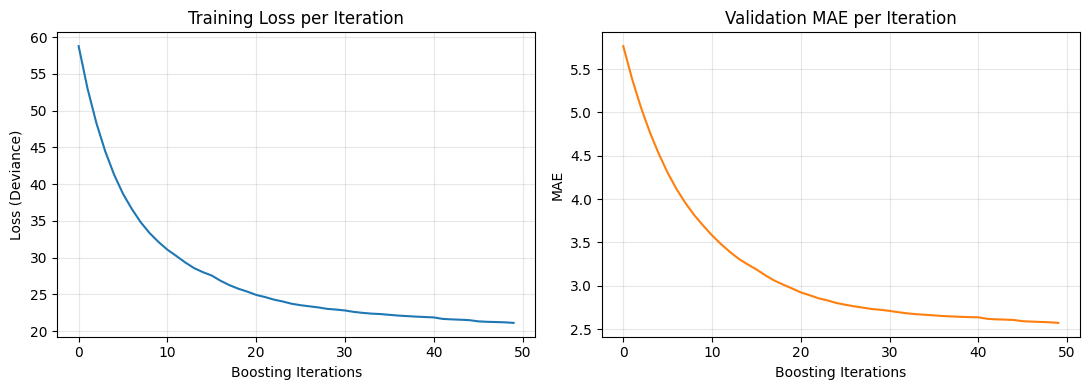

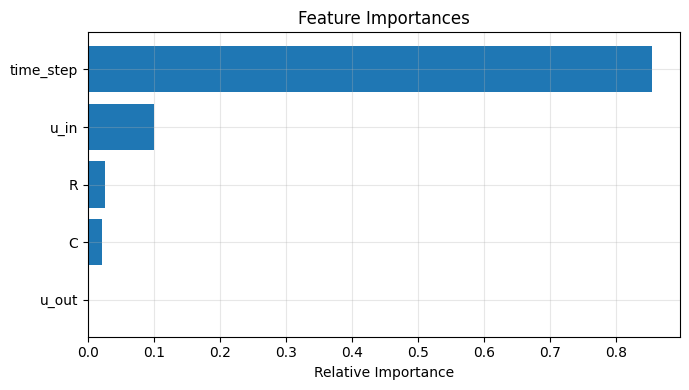

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Dynamically extract the exact feature names used in dataset.X
# Drop non-feature identifiers and target column
cols_to_exclude = {'id', 'breath_id', 'R_C', 'pressure'}
feature_names = [col for col in df_train.columns if col not in cols_to_exclude]

# 2. Extract arrays from your dataset objects (handling torch tensors or numpy arrays)
X_val_eval = val.X.cpu().numpy() if hasattr(val.X, "cpu") else np.asarray(val.X)
y_val_eval = val.y.cpu().numpy().ravel() if hasattr(val.y, "cpu") else np.asarray(val.y).ravel()

# -----------------------------------------------------------
# Metric Calculations across Boosting Stages
# -----------------------------------------------------------
val_mae_per_stage = [
    mean_absolute_error(y_val_eval, stage_preds)
    for stage_preds in ml_model.staged_predict(X_val_eval)
]

# -----------------------------------------------------------
# Graph 1: Loss & Validation Curve
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ml_model.train_score_, color='tab:blue', linewidth=1.5)
axes[0].set_title('Training Loss per Iteration')
axes[0].set_xlabel('Boosting Iterations')
axes[0].set_ylabel('Loss (Deviance)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_mae_per_stage, color='tab:orange', linewidth=1.5)
axes[1].set_title('Validation MAE per Iteration')
axes[1].set_xlabel('Boosting Iterations')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Graph 2: Feature Importance (Correctly Labeled)
# -----------------------------------------------------------
importances = ml_model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(7, 4))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Feature Importances')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Pressure Prediction (Breath 1)'}, xlabel='time_step'>

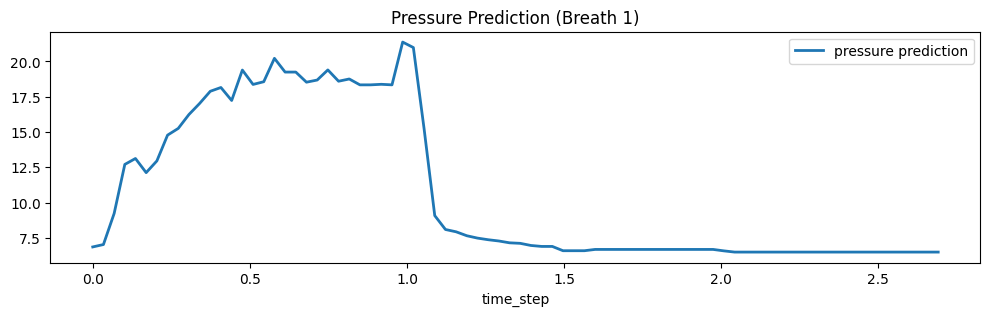

In [ ]:
import pandas as pd

# 1. Build a clean 2-column DataFrame
plot_df = pd.DataFrame({
    'time_step': df_train['time_step'].iloc[:80].values,
    'pressure prediction': ml_model.predict(train.X[:80])
})

# 2. Plot directly
plot_df.plot(
    x='time_step', 
    y='pressure prediction', 
    kind='line', 
    figsize=(12, 3), 
    lw=2, 
    title='Pressure Prediction (Breath 1)'
)

<Axes: title={'center': 'Actual vs Predicted Pressure (Breath 1)'}, xlabel='time_step'>

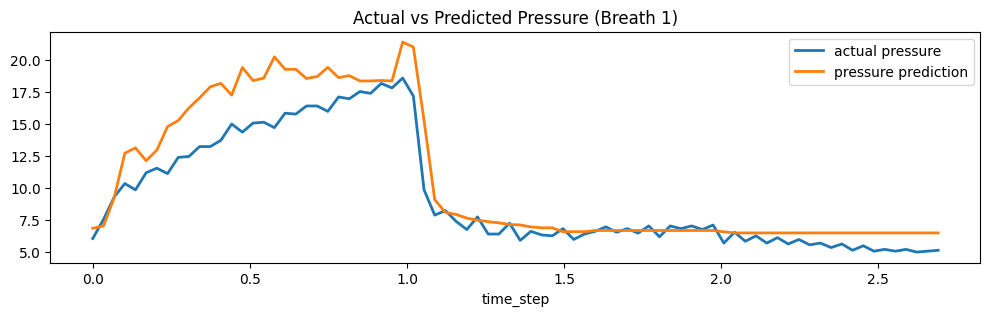

In [36]:
plot_df['actual pressure'] = train.y[:80].cpu().numpy().ravel() if hasattr(train.y, "cpu") else train.y[:80].ravel()

plot_df.plot(
    x='time_step', 
    y=['actual pressure', 'pressure prediction'], 
    kind='line', 
    figsize=(12, 3), 
    lw=2, 
    title='Actual vs Predicted Pressure (Breath 1)'
)

#### **DL model**

In [16]:
train_dataloader = DataLoader(train, batch_size=80, shuffle=False)
val_dataloader   = DataLoader(val, batch_size=80, shuffle=False)

In [17]:
class PressureMLP(nn.Module):
    def __init__(self, in_features):
        super(PressureMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

In [18]:
!pip install pytorch_lightning

In [19]:
import pytorch_lightning as pl

class LitPressureMLP(pl.LightningModule):
    def __init__(self, lr=1e-3, loss=nn.MSELoss):
        super().__init__()
        self.model = PressureMLP(train.X.shape[1])
        self.loss = loss
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = x.float()
        y = y.float()
        preds = self(x)
        loss = self.loss(preds, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    # def train_dataloader():


    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr)
        return optimizer

In [20]:
dl_model_mse = LitPressureMLP(loss=nn.MSELoss())
trainer = pl.Trainer(
    max_epochs=1,
    limit_train_batches=0.05,
    accelerator="auto"
)
trainer.fit(model=dl_model_mse, train_dataloaders=train_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PressureMLP │ 15.2 K │ train │     0 │
│ 1 │ loss  │ MSELoss     │      0 │ train │     0 │
└───┴───────┴─────────────┴────────┴───────┴───────┘

Trainable params: 15.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.2 K                                                                                               
Total estimated model params size (MB): 0.061                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size 
(torch.Size([80])) that is different to the input size (torch.Size([80, 1])). This will likely lead to incorrect 
results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


In [21]:
import torch, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on val
dl_model_mse.eval()
with torch.no_grad():
    y_pred = dl_model_mse(val.X.float().to(dl_model_mse.device)).cpu().numpy().ravel()
    test_preds = dl_model_mse(test.X.float().to(dl_model_mse.device)).cpu().numpy().ravel()

# Metrics
print(f"MeanAE: {mean_absolute_error(val.y, y_pred):.4f}")
print(f"MeanSE: {mean_squared_error(val.y, y_pred):.4f}")
print(f"TolAcc: {np.mean(np.abs(np.asarray(val.y).ravel() - y_pred) <= 5):.4f}")

# Submit
pd.DataFrame({'id': df_test['id'], 'pressure': test_preds}).to_csv('dl_submission.csv', index=False)

MeanAE: 6.0155
MeanSE: 67.8652
TolAcc: 0.6182


In [ ]:
# !kaggle competitions submit -c ventilator-pressure-prediction -f dl_submission.csv -m "Lightning MLP 0"

100% 66.6M/66.6M [00:01<00:00, 39.0MB/s]
Successfully submitted to Google Brain - Ventilator Pressure Prediction